## Prediction of Customer Churn for Naijaconnect Company

In [56]:
#import all needed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, confusion_matrix, recall_score
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, f_classif

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('NaijaConnect_Dataset.csv')

In [3]:
df.head()

,customer_id,age,gender,state,city,zone,education_level,occupation,primary_language,income_level,...,uses_mobile_money,uses_ussd_banking,subscribes_to_news,uses_social_bundles,family_plan,referrals_made,competitor_offers_received,device_age_years,smartphone_user,churn
0,NIG000001,34,Female,Yobe,Yobe City,North East,OND/NCE,Trader,English,Low,...,1,1,0,1,0,0,0,4.8,1,0
1,NIG000002,32,Female,Sokoto,Sokoto City,North West,Primary,Sales Rep,Igbo,Low,...,1,1,0,1,0,3,6,0.1,0,1
2,NIG000003,45,Male,Osun,Osun City,South West,Masters,Trader,Hausa,High,...,0,1,1,1,0,1,3,0.7,0,1
3,NIG000004,39,Male,Kaduna,Kaduna,North West,OND/NCE,Banker,Hausa,Low,...,1,1,1,1,0,1,7,0.7,1,0
4,NIG000005,58,Male,Nasarawa,Nasarawa City,North Central,HND/BSc,Accountant,Igbo,Middle,...,0,1,0,1,0,2,6,0.7,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 50000 non-null  object 
 1   age                         50000 non-null  int64  
 2   gender                      50000 non-null  object 
 3   state                       50000 non-null  object 
 4   city                        50000 non-null  object 
 5   zone                        50000 non-null  object 
 6   education_level             50000 non-null  object 
 7   occupation                  50000 non-null  object 
 8   primary_language            50000 non-null  object 
 9   income_level                50000 non-null  object 
 10  provider                    50000 non-null  object 
 11  plan_type                   50000 non-null  object 
 12  tenure_months               50000 non-null  int64  
 13  registration_date           500

In [5]:
df.isnull().sum()

customer_id                   0
age                           0
gender                        0
state                         0
city                          0
zone                          0
education_level               0
occupation                    0
primary_language              0
income_level                  0
provider                      0
plan_type                     0
tenure_months                 0
registration_date             0
monthly_charges               0
total_charges                 0
data_usage_gb                 0
voice_usage_minutes           0
sms_usage                     0
network_type                  0
call_drop_rate                0
network_downtime_hours        0
internet_speed_mbps           0
customer_service_calls        0
complaint_resolution_time     0
satisfaction_score            0
payment_method                0
late_payments                 0
has_caller_tune               0
has_data_rollover             0
has_international_roaming     0
uses_mob

In [6]:
df = df.drop(columns=['customer_id'], axis=1)

In [7]:
df.columns 

Index(['age', 'gender', 'state', 'city', 'zone', 'education_level',
       'occupation', 'primary_language', 'income_level', 'provider',
       'plan_type', 'tenure_months', 'registration_date', 'monthly_charges',
       'total_charges', 'data_usage_gb', 'voice_usage_minutes', 'sms_usage',
       'network_type', 'call_drop_rate', 'network_downtime_hours',
       'internet_speed_mbps', 'customer_service_calls',
       'complaint_resolution_time', 'satisfaction_score', 'payment_method',
       'late_payments', 'has_caller_tune', 'has_data_rollover',
       'has_international_roaming', 'uses_mobile_money', 'uses_ussd_banking',
       'subscribes_to_news', 'uses_social_bundles', 'family_plan',
       'referrals_made', 'competitor_offers_received', 'device_age_years',
       'smartphone_user', 'churn'],
      dtype='object')

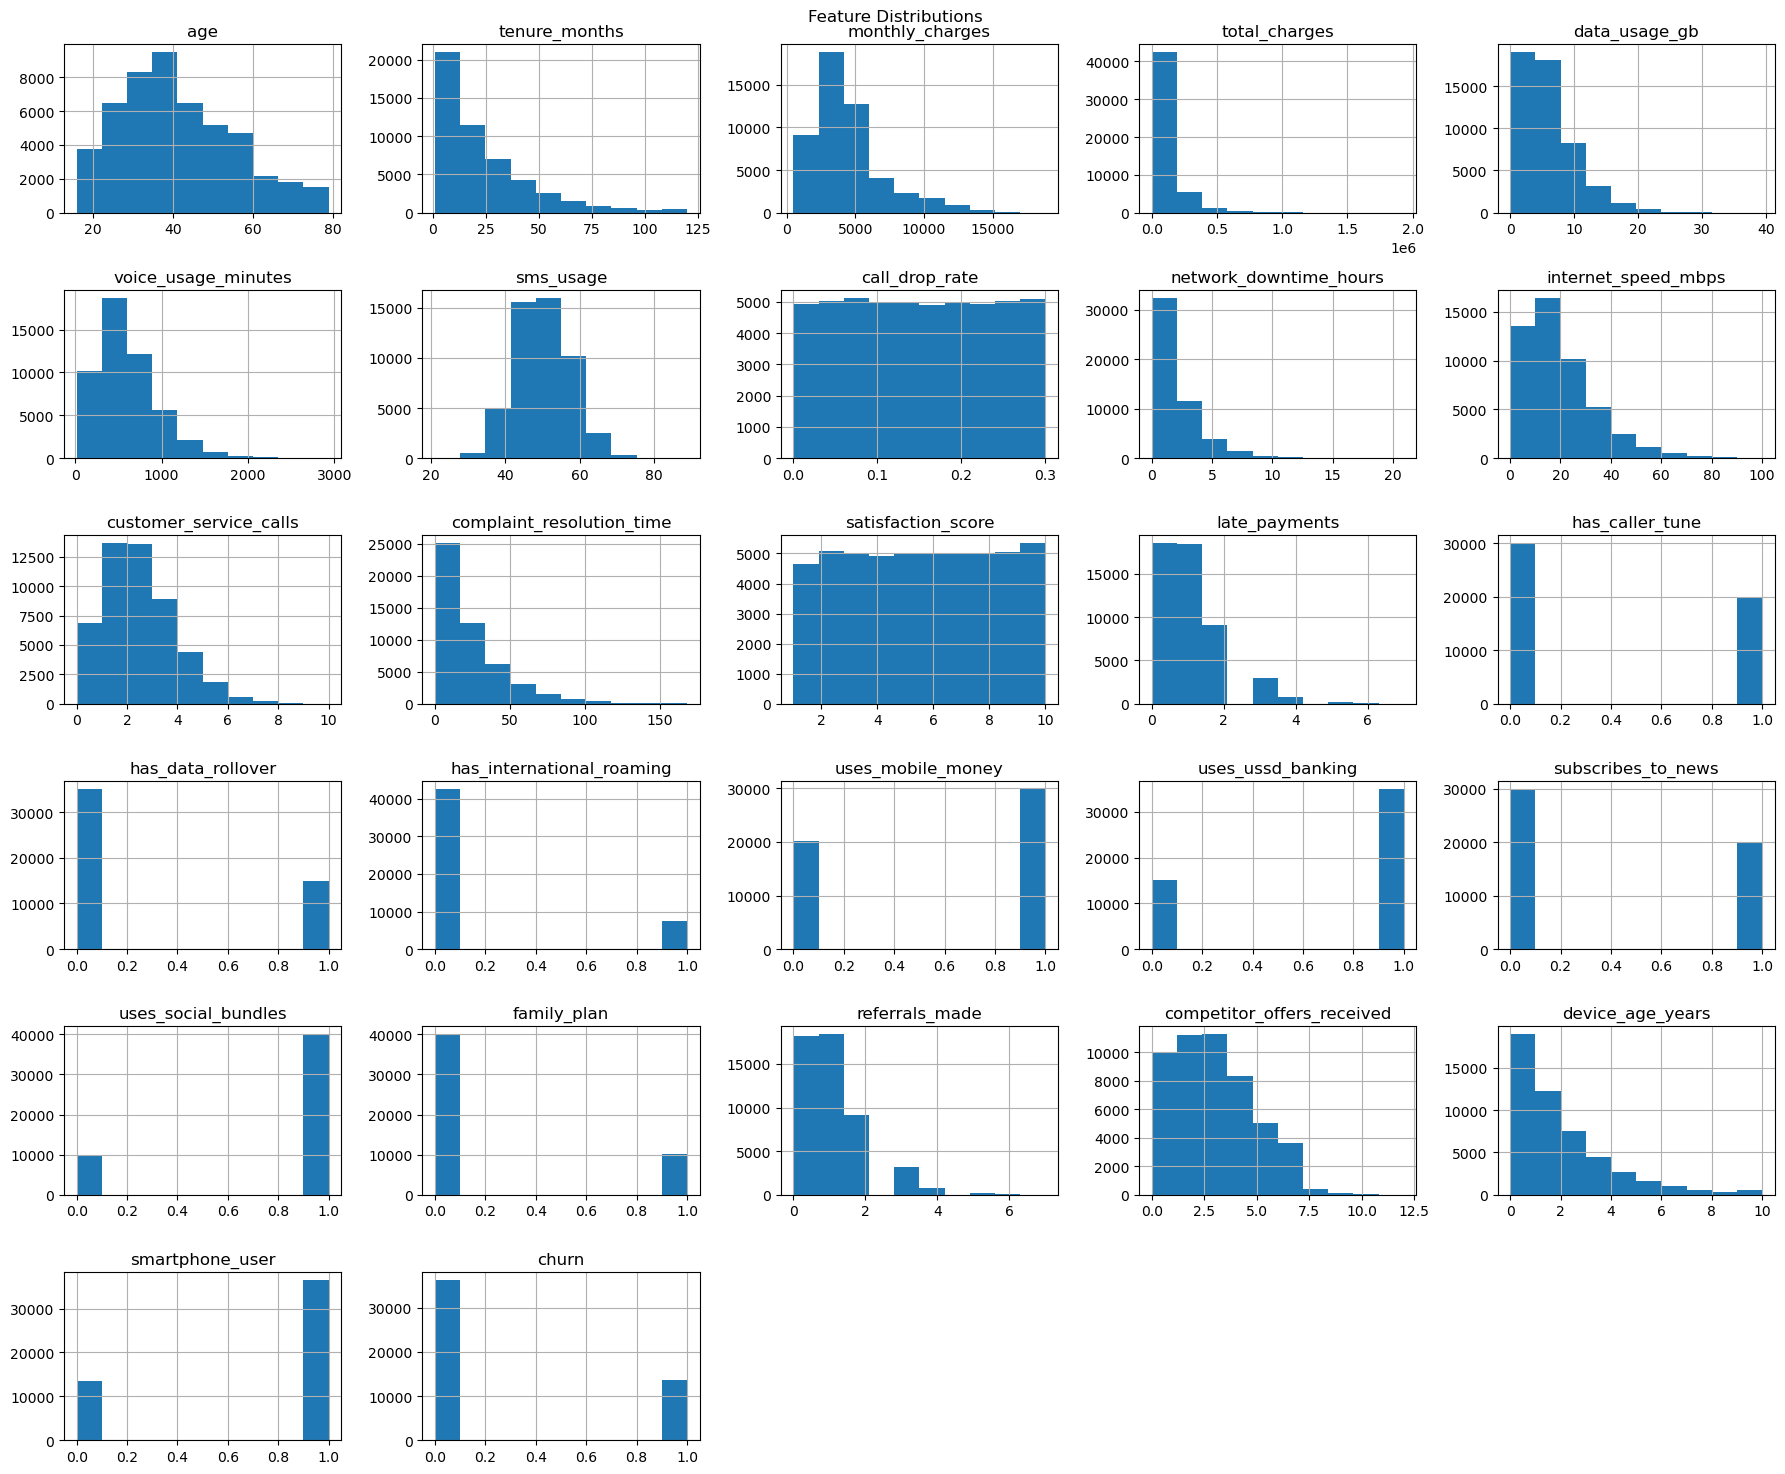

In [8]:
df.hist(figsize=(18, 15))
plt.suptitle('Feature Distributions')
plt.tight_layout();

In [9]:
# displaying the target variable
df['churn'].value_counts()

churn
0    36258
1    13742
Name: count, dtype: int64

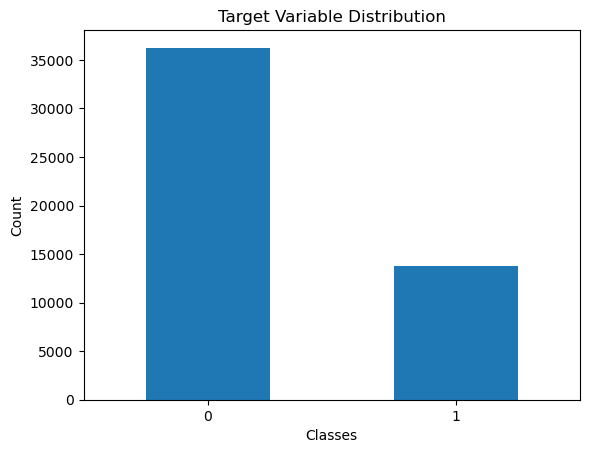

In [10]:
df['churn'].value_counts().plot(kind='bar')
plt.title('Target Variable Distribution')
plt.xlabel('Classes')
plt.ylabel('Count')
plt.xticks(rotation=0);

# Features Engineering

This is will enable us create new features(columns) that are needed for a more realistic analysis. These features we will be looking at are:

- service_experience_score
- competitors_risk_level
- digital_engagment_level
- usage_efficiency_level
- customer_value_score
- high_value_customer_satistfaction

In [11]:
len(df.columns)

40

In [12]:
# customer value score
df['customer_value_score'] = df['monthly_charges'] + df['total_charges'] / (df['tenure_months']+1)

In [13]:
df['customer_value_score'].value_counts()

customer_value_score
5656.035000     2
4733.460000     2
7745.600000     2
9671.680000     2
6779.420000     2
               ..
6977.836000     1
4000.947231     1
5923.283333     1
7090.557059     1
10539.150741    1
Name: count, Length: 49983, dtype: int64

In [14]:
# customer service experience: This keeps records of the ratings by the customers for the services offere by this company
df['service_experience_score'] = (
    df['satisfaction_score'] +
    df['network_downtime_hours'] +
    df['internet_speed_mbps'] +
    df['call_drop_rate'] +
    df['complaint_resolution_time']
)

In [15]:
# competitors risk level: This keeps reords of how likely a customer is to switch to another competitor, this will help in proper decision making 
df['competitors_risk_level'] = (
    df['competitor_offers_received'] / (df['tenure_months'] + 1) + df['satisfaction_score']
)

In [16]:
# usage efficiency level: How efficient are the services gotten to their set goals
df['usage_efficiency_level'] = (
    df['sms_usage'] + 
    df['data_usage_gb'] +
    df['voice_usage_minutes']
) / (df['monthly_charges'] + 1)

In [17]:
# digital_engagment_level: This allows for the tracking of how customers engages the digital platforms(social media presence) of this company
df['digital_engagment_level'] = (
    df['uses_mobile_money'] +
    df['uses_social_bundles'] +
    df['uses_ussd_banking'] +
    df['smartphone_user']
)

In [18]:
# high_value_customer_satistfaction: this tracks the satisfaction level of high network customers for this business
df['high_value_customer_satistfaction'] = (
    (df['monthly_charges'] >= df['monthly_charges'].quantile(0.75)) &
    (df['satisfaction_score'] < 5 )
)

In [19]:
len(df.columns)

46

# Features Encoding

Feature encoding is the process of converting categorical data into numerical formats so that machine learning models can process it effectively

In [20]:
# extracting all categorical variables
df_categoricals = df.select_dtypes(include = ['object'])

In [21]:
df_categoricals.dtypes

gender               object
state                object
city                 object
zone                 object
education_level      object
occupation           object
primary_language     object
income_level         object
provider             object
plan_type            object
registration_date    object
network_type         object
payment_method       object
dtype: object

In [22]:
# encoding the gender column
df_categoricals['gender'].value_counts()

gender
Male      26051
Female    23949
Name: count, dtype: int64

In [23]:
le = LabelEncoder()
df_categoricals['gender'] = le.fit_transform(df['gender'])

In [24]:
# encoding the state column using the frequency method
freq = df_categoricals['state'].value_counts()/len(df_categoricals)
df_categoricals['state'] = df_categoricals['state'].map(freq)

In [25]:
# encoding the zone column 
df_categoricals['zone'].value_counts()

zone
South West       12544
North West       11301
North Central     7166
South South       6967
North East        6020
South East        6002
Name: count, dtype: int64

In [26]:
# # encoding the zone with onehotencoder
he = OneHotEncoder(sparse_output=False)
encoded_zone = he.fit_transform(df_categoricals[['zone']])
# converting the encoded columns to dataframe
encoded_zone_df = pd.DataFrame(encoded_zone, columns = he.get_feature_names_out(['zone']))
# concatenating the encoded columns back to the dataset
df_categoricals = pd.concat([df_categoricals, encoded_zone_df], axis = 1)
# dropping the zone column
df_categoricals.drop(columns = 'zone', inplace=True)

In [27]:
# encoding the city column using the frequency method
freq_1 = df_categoricals['city'].value_counts()/len(df_categoricals)
df_categoricals['city'] = df_categoricals['city'].map(freq_1)

In [28]:
df_categoricals.columns 

Index(['gender', 'state', 'city', 'education_level', 'occupation',
       'primary_language', 'income_level', 'provider', 'plan_type',
       'registration_date', 'network_type', 'payment_method',
       'zone_North Central', 'zone_North East', 'zone_North West',
       'zone_South East', 'zone_South South', 'zone_South West'],
      dtype='object')

In [29]:
# # encoding the payment method with onehotencoder
he = OneHotEncoder(sparse_output=False)
encoded_payment = he.fit_transform(df_categoricals[['payment_method']])
# converting the encoded columns to dataframe
encoded_payment_df = pd.DataFrame(encoded_payment, columns = he.get_feature_names_out(['payment_method']))
# concatenating the encoded columns back to the dataset
df_categoricals = pd.concat([df_categoricals, encoded_payment_df], axis = 1)
# dropping the payment method column
df_categoricals.drop(columns = 'payment_method', inplace=True)

In [30]:
le_network_type = LabelEncoder()
df_categoricals['network_type'] = le_network_type.fit_transform(df['network_type'])

In [31]:
# # encoding the plan_type with onehotencoder
he = OneHotEncoder(sparse_output=False)
encoded_plan_type = he.fit_transform(df_categoricals[['plan_type']])
# converting the encoded columns to dataframe
encoded_plan_type = pd.DataFrame(encoded_plan_type, columns = he.get_feature_names_out(['plan_type']))
# concatenating the encoded columns back to the dataset
df_categoricals = pd.concat([df_categoricals, encoded_plan_type], axis = 1)
# dropping the plan_type column
df_categoricals.drop(columns = 'plan_type', inplace=True)

In [32]:
# # encoding the provider with onehotencoder
he = OneHotEncoder(sparse_output=False)
encoded_provider = he.fit_transform(df_categoricals[['provider']])
# converting the encoded columns to dataframe
encoded_provider_df = pd.DataFrame(encoded_provider, columns = he.get_feature_names_out(['provider']))
# concatenating the encoded columns back to the dataset
df_categoricals = pd.concat([df_categoricals, encoded_provider_df], axis = 1)
# dropping the provider column
df_categoricals.drop(columns = 'provider', inplace=True)

In [33]:
# ordinal encoding 
income_status = ['Low', 'Middle', 'High']
value_mapping = {status: j + 1 for j, status in enumerate(income_status)}

df_categoricals['income_level'] = df_categoricals['income_level'].map(value_mapping)

In [34]:
# # encoding the primary_language with onehotencoder
he = OneHotEncoder(sparse_output=False)
encoded_language = he.fit_transform(df_categoricals[['primary_language']])
# converting the encoded columns to dataframe
encoded_language_df = pd.DataFrame(encoded_language, columns = he.get_feature_names_out(['primary_language']))
# concatenating the encoded columns back to the dataset
df_categoricals = pd.concat([df_categoricals, encoded_language_df], axis = 1)
# dropping the primary_language column
df_categoricals.drop(columns = 'primary_language', inplace=True)

In [35]:
# encoding the city column using the frequency method
freq_2 = df_categoricals['occupation'].value_counts()/len(df_categoricals)
df_categoricals['occupation'] = df_categoricals['occupation'].map(freq_2)

In [36]:
# ordinal encoding of the educational level
education_order = ['No Formal Education', 'Primary', 'Secondary', 'OND/NCE', 'HND/BSc', 'Masters', 'PhD']
values_mapping = {level: v + 1 for v, level in enumerate(education_order)}

df_categoricals['education_level'] = df_categoricals['education_level'].map(values_mapping)

In [37]:
df_categoricals['registration_date'] = pd.to_datetime(df_categoricals['registration_date'])
df_categoricals['days_since_registration'] = (pd.Timestamp("today") - df_categoricals['registration_date']).dt.days
df_categoricals['month-of-registration'] = df_categoricals['registration_date'].dt.month
df_categoricals['year-of-registration'] = df_categoricals['registration_date'].dt.year
df_categoricals = df_categoricals.drop(columns=['registration_date'])

# Merging the original numerical columns with the encoded columns 

In [38]:
# displaying all encoded categorial columns 
len(df_categoricals.dtypes)

38

In [39]:
# extracting all numerical columns from the original data 
df_numerical = df.select_dtypes(include = ['int64', 'float64', 'bool'])

In [40]:
len(df_numerical.dtypes)

33

In [41]:
# concatenating the df_categoricals_encoded and df_numerical
df_1 = pd.concat([df_categoricals, df_numerical], axis=1)

In [42]:
len(df_1.columns)

71

# Features Dimentionality Reduction

In [43]:
# spliting data into X and y 
X = df_1.drop(columns='churn')
y = df['churn']

In [44]:
# defining a function for features reduction
def features_reduction(X, y, target_features=30):
    """ This function reduces the number of features optimally 
        to a more reasonably defined number of features 
    """

    # removing features with low variance
    var_threshold = VarianceThreshold(threshold=0.01)
    X_var = var_threshold.fit_transform(X)

    # remaining feature names after variance threshold
    features_after_var = X.columns[var_threshold.get_support()]

    # checking statistical significance of the selected features
    k_features = min(target_features, X_var.shape[1])
    f_selector = SelectKBest(score_func=f_classif, k=k_features)
    X_new = f_selector.fit_transform(X_var, y)

    # getting selected feature names
    features_selected = features_after_var[f_selector.get_support()]

    # keeping DataFrame with feature names
    df_reduced = pd.DataFrame(X_new, columns=features_selected, index=X.index)

    results = {
        'df_reduced': df_reduced,
        'n_features': df_reduced.shape[1],
        'variance_selector': var_threshold,
        'f_selector': f_selector,
        'selected_features': features_selected
    }

    return results

In [45]:
# Applying feature reduction
results = features_reduction(X, y, target_features=30)

# Replacing X with reduced features
X = results['df_reduced']
X.head()

,payment_method_Airtime Transfer,plan_type_Hybrid,plan_type_Postpaid,plan_type_Prepaid,provider_9mobile,provider_Glo,primary_language_English,primary_language_Yoruba,days_since_registration,month-of-registration,...,uses_mobile_money,family_plan,referrals_made,competitor_offers_received,customer_value_score,service_experience_score,competitors_risk_level,usage_efficiency_level,digital_engagment_level,high_value_customer_satistfaction
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,716.0,10.0,...,1.0,0.0,0.0,0.0,11105.723478,56.460,1.400000,0.017489,4.0,1.0
1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,686.0,10.0,...,1.0,0.0,3.0,6.0,9068.246364,58.906,7.672727,0.049331,3.0,0.0
2,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,86.0,6.0,...,0.0,0.0,1.0,3.0,3725.740000,37.062,6.300000,0.409897,2.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,686.0,10.0,...,1.0,0.0,1.0,7.0,5743.167727,57.022,8.618182,0.225852,4.0,0.0
4,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,386.0,8.0,...,0.0,0.0,2.0,6.0,3859.365000,111.842,5.900000,0.287009,2.0,0.0


# Splitting Data into testing and training

In [46]:
# splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1, stratify=y)

# scalling the dataset
scalar=StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

# converting the scaled data into a dataframe
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Feature Selection

In [47]:
# using f_classif module to select the most important features
selector = SelectKBest(score_func=f_classif, k=10)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

selected_features_names = X_train_scaled.columns[selector.get_support()]

# converting the scaled data into a dataframe
X_train_selected = pd.DataFrame(X_train_selected, columns= selected_features_names, index=X_train.index)
X_test_selected = pd.DataFrame(X_test_selected, columns= selected_features_names, index=X_test.index)

# Features Importance

In [48]:
# Getting the features importance
random_f = RandomForestClassifier(n_estimators = 100, random_state = 1)
random_f.fit(X_train_selected, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


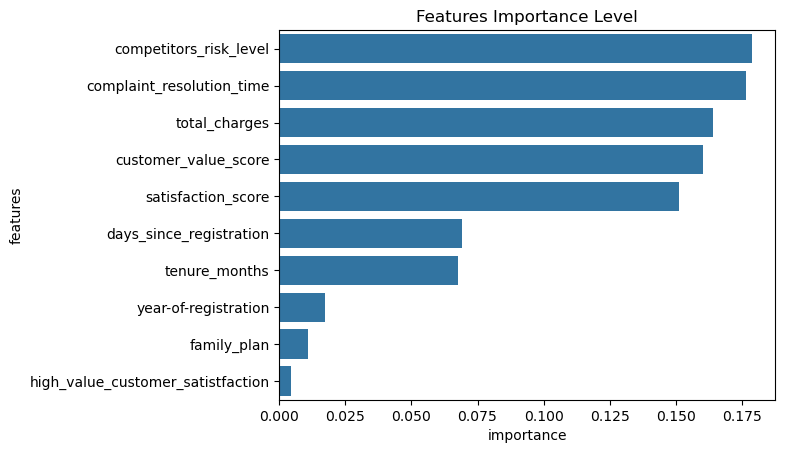

In [49]:
# plotting the features importance
features_importance = pd.DataFrame({
    'features': X_train_selected.columns,
    'importance': random_f.feature_importances_
}).sort_values('importance', ascending=False)

# plotting
sns.barplot(data=features_importance, x = 'importance', y='features')
plt.title('Features Importance Level');

# Model Building

In [76]:
models = {
    'Logistics Regression': LogisticRegression(random_state=1, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=1)
}

result = {}

for name, model in models.items():
    # printing the models name
    print(f'\nTraining {name}')
    model.fit(X_train_selected, y_train)

    # testing the model using the test data
    y_pred = model.predict(X_test_selected)

    # metric for model performance (evaluating the model performance)
    test_accuracy=accuracy_score(y_test, y_pred)
    test_precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    test_recal = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_test = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cv = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='accuracy').mean()

    result[name] = {
        'model':model,
        'test_accuracy':test_accuracy,
        'test_precision':test_precision,
        'test_recal':test_recal,
        'f1_test':f1_test,
        'cv':cv
    }

    # displayingthe above results
    print(f'Test Accuracy: {test_accuracy:.3f}')
    print(f'Test Precision: {test_precision:.3f}')
    print(f'Test Recall: {test_recal:.3f}')
    print(f'F1 Test: {f1_test:.3f}')
    print(f'CV Score: {cv:.3f}')


Training Logistics Regression
Test Accuracy: 0.735
Test Precision: 0.700
Test Recall: 0.735
F1 Test: 0.690
CV Score: 0.740

Training Random Forest
Test Accuracy: 0.731
Test Precision: 0.701
Test Recall: 0.731
F1 Test: 0.703
CV Score: 0.730

Training Gradient Boosting
Test Accuracy: 0.748
Test Precision: 0.720
Test Recall: 0.748
F1 Test: 0.707
CV Score: 0.748


# Hyperparameter Tunning

In [79]:
param_grid = {
    'Logistic Regression': {
        'C': [0.1, 1.0],
        'solver': ['liblinear', 'lbfgs']
    },
    'Random Forest': {
        'n_estimators':[50, 100],
        'max_depth':[None, 20],
        'min_samples_split': [2, 10]
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100],
        'learning_rate': [0.1, 0.2],
        'max_depth': [3, 7]
    }
}

tuned_models = {}

for name in result:
    if name not in param_grid:
        print(f'\n{name} has no parameter for tuning')
        tuned_models[name] = result[name]['model']
        continue

    print(f'\nTuning hyperparameters for {name}')
    base_model = result[name]['model']
    param_grids = param_grid[name]

    grid_search = GridSearchCV(
        base_model,
        param_grids,  
        cv=3,
        n_jobs=-1,
        scoring='accuracy'
    )
    grid_search.fit(X_train_selected, y_train)

    best_estimator = grid_search.best_estimator_  
    tuned_models[name] = best_estimator

    print(f' Best Parameters: {grid_search.best_params_}')
    print(f' Best CV Accuracy: {grid_search.best_score_:.3f}')



Logistics Regression has no parameter for tuning

Tuning hyperparameters for Random Forest
 Best Parameters: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 100}
 Best CV Accuracy: 0.737

Tuning hyperparameters for Gradient Boosting
 Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
 Best CV Accuracy: 0.748


# Object Oriented Programming

In [67]:
class Girl:
    def __init__(self, name, address, city, state):
        self.name = name 
        self.address = address
        self.city = city
        self.state = state

        
    def girls_job(self):
        return f'The girl called {self.name} is a very brilliant student of machine learining, and she lives at {self.address} in Port Harcourt of Rivers state'

    def education(self):
        return f'The girl called {self.name} is a graduate of Agric science from the univerity of {self.city} whih is loated in {self.state}'
    
    def future_ambition(self):
        return f'{self.name} is aspiring to be a machine learning engineer in the nearest future, she is very dedicated in getting to that level'

# calling the class
x = Girl('Glory', 'Woji', 'Port Harcourt', 'Rivers State')
print(f'My name is {x.name}')
print(f'I live at {x.address} in {x.city} of {x.state}')
print(x.girls_job())
print(x.education())
print(x.future_ambition())

My name is Glory
I live at Woji in Port Harcourt of Rivers State
The girl called Glory is a very brilliant student of machine learining, and she lives at Woji in Port Harcourt of Rivers state
The girl called Glory is a graduate of Agric science from the univerity of Port Harcourt whih is loated in Rivers State
Glory is aspiring to be a machine learning engineer in the nearest future, she is very dedicated in getting to that level
